In [ ]:
#########################################################""

In [1]:
pip install sentence_transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pykeen

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.


**Import Required Libraries**


In [4]:
import pandas as pd
import networkx as nx
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from sklearn.model_selection import train_test_split
import torch
torch.manual_seed(0)

**Load and Preprocess Knowledge Base**

In [5]:
# Load knowledge base and initialize the graph
knowledge_base = pd.read_csv("/kaggle/input/concat/Concat.csv")
graph = nx.DiGraph()

**Building a Knowledge Graph from Dataset Triples**

This code processes a dataset to create a knowledge graph by iterating through each row, extracting head, relation, and tail triples, and adding them as nodes and directed edges in the graph. It also enriches each node with attributes like definition, synonym, reference, and process. This structured graph forms the foundation for building embeddings and performing reasoning tasks

In [6]:
# Create triples (head, relation, tail) from the dataset
triples = []
for _, row in knowledge_base.iterrows():
    head = str(row['Concepts']) if pd.notna(row['Concepts']) else None
    relation = str(row['Type_relation']) if pd.notna(row['Type_relation']) else None
    tail = str(row['Concept_of_type_relation']) if pd.notna(row['Concept_of_type_relation']) else None

    if head and relation and tail:  # Ensure all parts are non-null strings
        triples.append((head, relation, tail))
        # Add nodes and edges to the graph for visualization and evaluation
        if head not in graph:
            graph.add_node(head,
                           definition=row['Definition'] if pd.notna(row['Definition']) else '',
                           synonym=row['Synonym'] if pd.notna(row['Synonym']) else '',
                           reference=row['Reference'] if pd.notna(row['Reference']) else '',
                           process=row['Process_name'] if pd.notna(row['Process_name']) else '')
        if tail not in graph:
            graph.add_node(tail, definition='', synonym='', reference='', process='')
        graph.add_edge(head, tail, relation=relation)

**Visualizing a Knowledge Graph with Relationships**

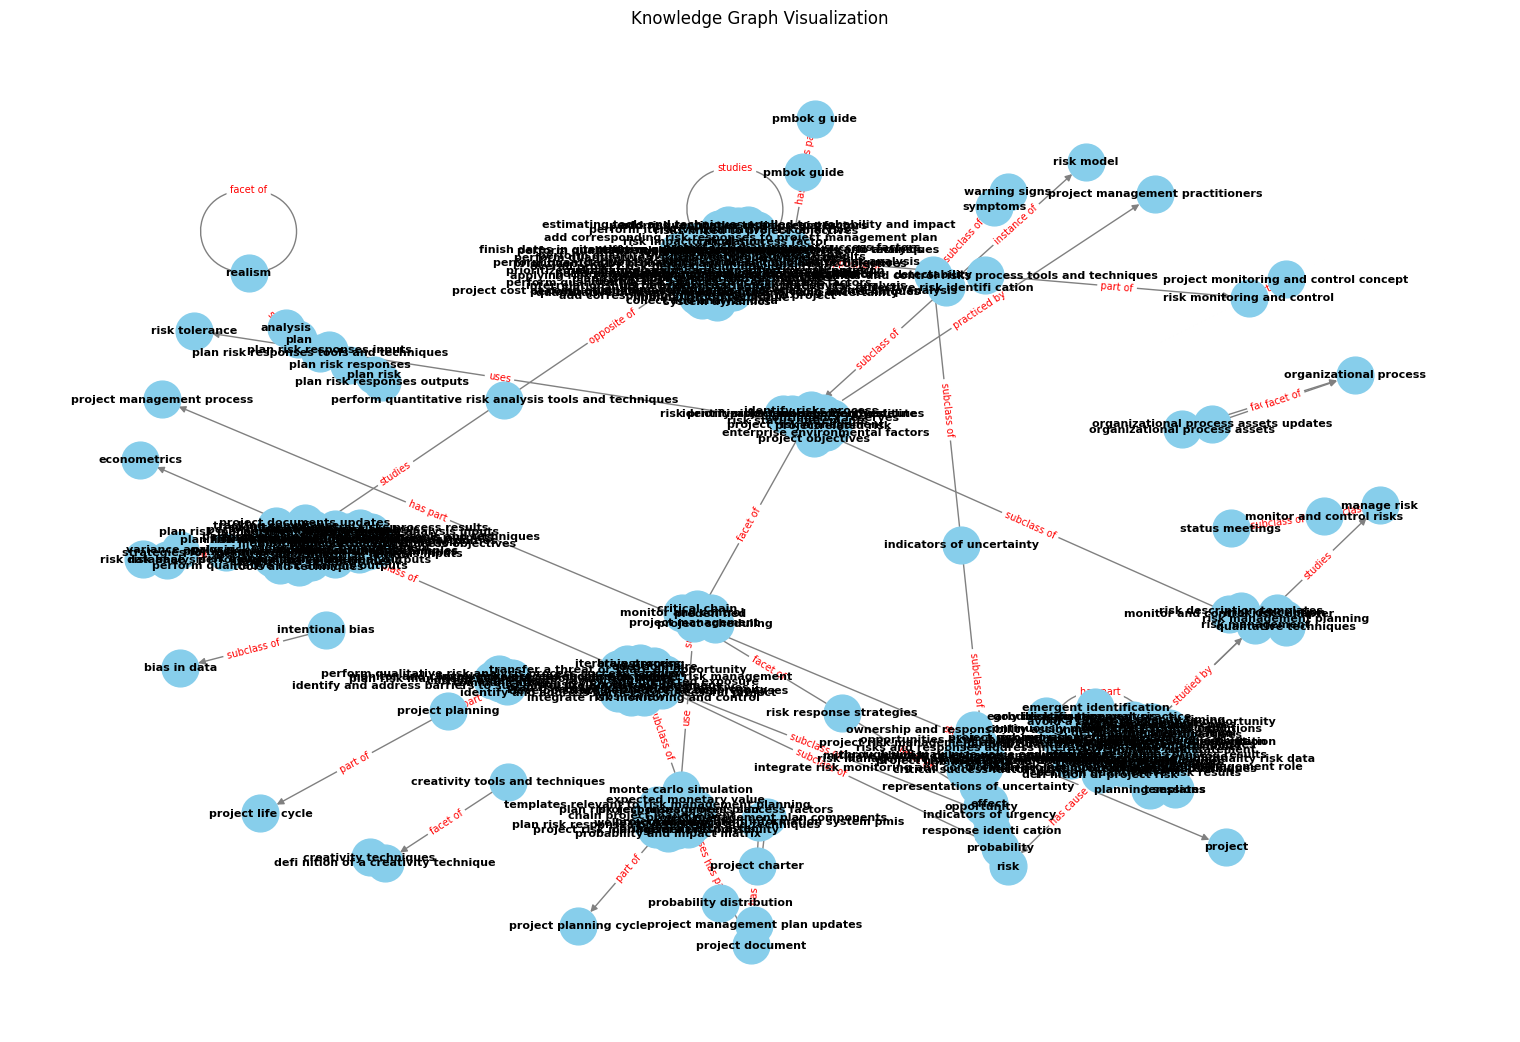

In [7]:
import matplotlib.pyplot as plt

# Define a layout for visualization (e.g., spring layout for a better spread)
pos = nx.spring_layout(graph)

# Draw the graph
plt.figure(figsize=(15, 10))
nx.draw(graph, pos, with_labels=True, node_size=700, node_color="skyblue", font_size=8, font_weight="bold", edge_color="gray")

# Draw edge labels to show relations
edge_labels = nx.get_edge_attributes(graph, 'relation')
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color="red", font_size=7)

plt.title("Knowledge Graph Visualization")
plt.show()

**Comprehensive Analysis of Graph Properties**

In [9]:
import networkx as nx

# Function to print basic information about the graph
def evaluate_graph_properties(graph):
    # Check if the graph is directed
    is_directed = nx.is_directed(graph)
    print(f"Graph is directed: {is_directed}")

    # Check if the graph is connected (only for undirected graphs)
    if is_directed:
        is_strongly_connected = nx.is_strongly_connected(graph)
        is_weakly_connected = nx.is_weakly_connected(graph)
        print(f"Graph is strongly connected: {is_strongly_connected}")
        print(f"Graph is weakly connected: {is_weakly_connected}")
    else:
        is_connected = nx.is_connected(graph)
        print(f"Graph is connected: {is_connected}")

    # Print the number of nodes and edges
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    print(f"Number of nodes: {num_nodes}")
    print(f"Number of edges: {num_edges}")

    # Print information about the density of the graph
    density = nx.density(graph)
    print(f"Graph density: {density:.4f}")

    # Print basic statistics about the degree of nodes
    degrees = [degree for _, degree in graph.degree()]
    avg_degree = sum(degrees) / len(degrees)
    print(f"Average node degree: {avg_degree:.2f}")

# Call the function to evaluate the properties of the graph
evaluate_graph_properties(graph)


Graph is directed: True
Graph is strongly connected: False
Graph is weakly connected: False
Number of nodes: 249
Number of edges: 247
Graph density: 0.0040
Average node degree: 1.98


**Preparing and Training a Knowledge Graph Embedding Model**

Main Objective: This code segment is focused on preparing the knowledge graph data for training and evaluating a graph embedding model using the TransE algorithm.

The objective is to generate and extract entity and relation embeddings for subsequent analysis or applications in tasks such as graph-based reasoning or similarity calculations.

In [11]:
# Convert triples to DataFrame and create TriplesFactory
triples_df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
triples_factory = TriplesFactory.from_labeled_triples(triples_df.values)

# Split the triples into training (80%), validation (10%), and testing (10%)
train_triples, test_val_triples = train_test_split(triples_df.values, test_size=0.2, random_state=42)
val_triples, test_triples = train_test_split(test_val_triples, test_size=0.5, random_state=42)

# Create TripleFactories for each set
train_factory = TriplesFactory.from_labeled_triples(train_triples)
val_factory = TriplesFactory.from_labeled_triples(val_triples)
test_factory = TriplesFactory.from_labeled_triples(test_triples)

# Run pipeline with TransE model
transE_model = pipeline(
    model='TransE',
    training=train_factory,
    testing=test_factory,
    validation=val_factory,
    model_kwargs=dict(embedding_dim=64),
    optimizer='Adam',
    training_kwargs=dict(num_epochs=100)
)

# Retrieve embeddings
entity_embeddings = transE_model.model.entity_representations[0]().detach().numpy()
relation_embeddings = transE_model.model.relation_representations[0]().detach().numpy()

print("Entity embeddings shape:", entity_embeddings.shape)
print("Relation embeddings shape:", relation_embeddings.shape)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0/1 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/1 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/1 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0/1 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/1 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/1 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/30.0 [00:00<?, ?triple/s]

Entity embeddings shape: (206, 64)
Relation embeddings shape: (12, 64)


**Evaluating the Performance of a Knowledge Graph Embedding Model**

In [13]:
from pykeen.evaluation import RankBasedEvaluator

# Create an evaluator instance
evaluator = RankBasedEvaluator()

# Evaluate the model on the test set
results = evaluator.evaluate(
    model=transE_model.model,
    mapped_triples=test_factory.mapped_triples,
    additional_filter_triples=[train_factory.mapped_triples, val_factory.mapped_triples]
)

# Print the detailed evaluation results
print("Evaluation Results:")
print(results.to_dict())  # Converts the result object to a dictionary for better readability


Evaluating on cpu:   0%|          | 0.00/30.0 [00:00<?, ?triple/s]

Evaluation Results:
{'head': {'optimistic': {'z_inverse_harmonic_mean_rank': 1.334347397008413, 'inverse_arithmetic_mean_rank': 0.009749756256093598, 'count': 30.0, 'standard_deviation': 59.46185518651619, 'median_rank': 111.0, 'median_absolute_deviation': 74.8714120345329, 'adjusted_arithmetic_mean_rank': 0.9943448052997252, 'adjusted_geometric_mean_rank_index': 0.0583916145308091, 'geometric_mean_rank': 73.50941128740648, 'z_geometric_mean_rank': 0.337672828206629, 'arithmetic_mean_rank': 102.56666666666666, 'adjusted_inverse_harmonic_mean_rank': 0.021227019122969128, 'z_arithmetic_mean_rank': 0.053911546635031726, 'harmonic_mean_rank': 20.253038731644008, 'variance': 3535.712222222222, 'inverse_harmonic_mean_rank': 0.04937530675026891, 'inverse_median_rank': 0.009009009009009009, 'inverse_geometric_mean_rank': 0.0136037002947855, 'adjusted_arithmetic_mean_rank_index': 0.005710556371349318, 'hits_at_1': 0.03333333333333333, 'hits_at_3': 0.03333333333333333, 'hits_at_5': 0.03333333333

**Visualizing Knowledge Graph with 2D Embedding Projection**

Main Objective: This code aims to visualize a knowledge graph by projecting entity embeddings into 2D space using t-SNE.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Apply t-SNE to project the embeddings into 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
entity_embeddings_2d = tsne.fit_transform(entity_embeddings)

# Map embeddings to graph nodes, ensuring we only include nodes that have embeddings
nodes_with_embeddings = list(graph.nodes)[:len(entity_embeddings_2d)]
pos = {node: entity_embeddings_2d[i] for i, node in enumerate(nodes_with_embeddings)}

# Filter edges to only include those between nodes with embeddings
edges_with_positions = [(u, v) for u, v in graph.edges if u in pos and v in pos]

# Draw the graph using the filtered nodes and edges
plt.figure(figsize=(15, 10))
nx.draw(graph, pos, nodelist=nodes_with_embeddings, edgelist=edges_with_positions,
        with_labels=True, node_size=700, node_color="lightblue", font_size=8, font_weight="bold", edge_color="gray")

# Draw edge labels for edges with both endpoints in pos
edge_labels = {edge: graph.edges[edge]['relation'] for edge in edges_with_positions}
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color="red", font_size=7)

plt.title("Knowledge Graph Visualization with Embeddings (2D Projection)")
plt.show()


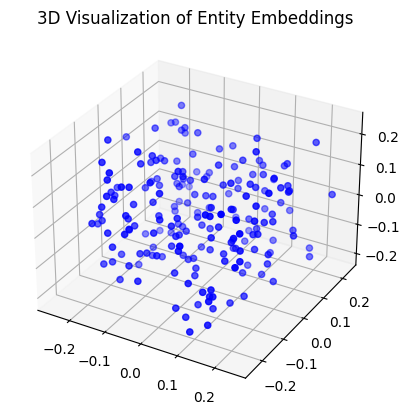

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 3D visualization of embeddings
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(entity_embeddings[:, 0], entity_embeddings[:, 1], entity_embeddings[:, 2], c='b', marker='o')
ax.set_title("3D Visualization of Entity Embeddings")
plt.show()

# Split data
from sklearn.model_selection import train_test_split
train_triples, test_val_triples = train_test_split(triples_df.values, test_size=0.2, random_state=42)
val_triples, test_triples = train_test_split(test_val_triples, test_size=0.5, random_state=42)

train_factory = TriplesFactory.from_labeled_triples(train_triples)
val_factory = TriplesFactory.from_labeled_triples(val_triples)
test_factory = TriplesFactory.from_labeled_triples(test_triples)


**Integrating TransE Embeddings into Knowledge Graph Nodes**

Main Objective: The main objective of this code is to enrich each node in the knowledge graph with its corresponding learned embedding from the TransE model. This step is essential for downstream tasks such as graph-based machine learning, where these node embeddings are used as input features for more complex models or analyses.

In [23]:
import torch

# Create dictionaries for quick access to entity and relation embeddings
entity_dict = {
    ent: torch.tensor(entity_embeddings[transE_model.training.entity_to_id[ent]]).detach()
    for ent in transE_model.training.entity_to_id
}

relation_dict = {
    rel: torch.tensor(relation_embeddings[transE_model.training.relation_to_id[rel]]).detach()
    for rel in transE_model.training.relation_to_id
}

# Add embeddings to each node in the graph as node features
for node in graph.nodes:
    graph.nodes[node]['embedding'] = entity_dict.get(node, torch.zeros(64))


**Converting NetworkX Graph to PyTorch Geometric Format with Node Features**

Main Objective: The main purpose of this code is to create a deep reasoning model that can process graph data using node embeddings and perform multi-task learning. It learns to make predictions or provide reasoning outputs related to definitions, synonyms, and relationships for nodes in the graph. The combination of convolutional layers and pooling ensures that information from the local neighborhood of each node and the overall graph structure are captured effectively.

Main Objective: This code converts a NetworkX graph into a format compatible with PyTorch Geometric

In [24]:
from torch_geometric.utils import from_networkx

# Convert to PyTorch Geometric format
graph_data = from_networkx(graph)

# Ensure node features are set to TransE embeddings
graph_data.x = torch.stack([graph.nodes[node]['embedding'] for node in graph.nodes])


In [25]:
for node in graph.nodes:
    embedding = graph.nodes[node].get('embedding', None)
    if embedding is not None:
        if isinstance(embedding, torch.Tensor):
            embedding = embedding.detach().cpu().numpy()  # Convert to numpy array
        if isinstance(embedding, (list, np.ndarray)):
            graph.nodes[node]['embedding'] = ",".join(map(str, embedding))

**Building a Deep Graph Neural Network for Multi-Task Reasoning on Node Embeddings**

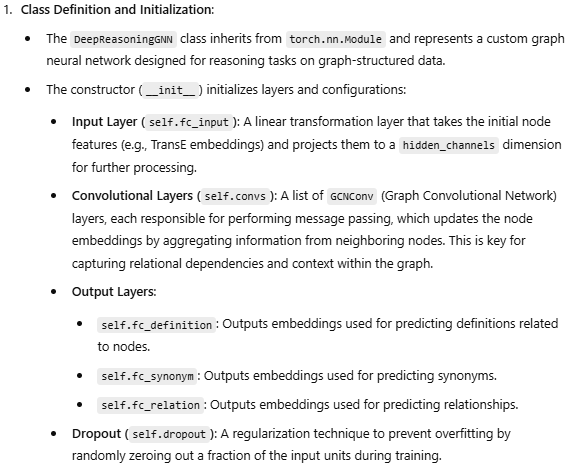

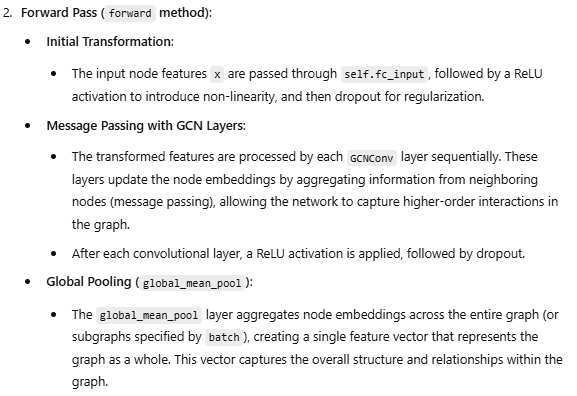

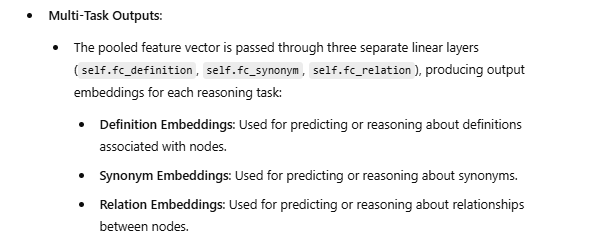

In [16]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class DeepReasoningGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=4, dropout_prob=0.5):
        super(DeepReasoningGNN, self).__init__()
        self.convs = torch.nn.ModuleList()

        # Initial layer to transform TransE embeddings
        self.fc_input = torch.nn.Linear(in_channels, hidden_channels)

        # Creating multiple convolutional layers to perform deep message passing
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        # Output layers for reasoning tasks: definition, synonym, and relation prediction
        self.fc_definition = torch.nn.Linear(hidden_channels, out_channels)
        self.fc_synonym = torch.nn.Linear(hidden_channels, out_channels)
        self.fc_relation = torch.nn.Linear(hidden_channels, out_channels)

        # Dropout for regularization
        self.dropout = torch.nn.Dropout(p=dropout_prob)

    def forward(self, x, edge_index, batch):
        # Initial transformation of input features
        x = F.relu(self.fc_input(x))
        x = self.dropout(x)

        # Apply each convolution layer followed by selective pooling
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = self.dropout(x)

        # Pooling to get an overall feature representation
        x = global_mean_pool(x, batch)

        # Output layers for multi-task predictions
        out_def = self.fc_definition(x)
        out_syn = self.fc_synonym(x)
        out_rel = self.fc_relation(x)

        return out_def, out_syn, out_rel


In [26]:
# Define optimizer and loss
model = DeepReasoningGNN(in_channels=64, hidden_channels=128, out_channels=64, num_layers=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

# Placeholder definitions for node-level features
graph_data.definitions = torch.rand((graph_data.num_nodes, 64))
graph_data.synonyms = torch.rand((graph_data.num_nodes, 64))
graph_data.relations = torch.rand((graph_data.num_edges, 64))

# Training function
def train_model(model, data, optimizer, criterion, epochs=100):
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Model forward pass
        out_def, out_syn, out_rel = model(data.x, data.edge_index, data.batch)

        # Calculate task-specific losses
        loss_def = criterion(out_def, data.definitions)
        loss_syn = criterion(out_syn, data.synonyms)
        loss_rel = criterion(out_rel, data.relations)

        total_loss = loss_def + loss_syn + loss_rel
        total_loss.backward()

        if epoch % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Total Loss: {total_loss.item():.4f}")

# Train the model on the graph data
train_model(model, graph_data, optimizer, criterion, epochs=100)


/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([249, 64])) that is different to the input size (torch.Size([1, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([247, 64])) that is different to the input size (torch.Size([1, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/100, Total Loss: 1.0310
Epoch 11/100, Total Loss: 1.0335
Epoch 21/100, Total Loss: 1.0316
Epoch 31/100, Total Loss: 1.0323
Epoch 41/100, Total Loss: 1.0322
Epoch 51/100, Total Loss: 1.0336
Epoch 61/100, Total Loss: 1.0325
Epoch 71/100, Total Loss: 1.0316
Epoch 81/100, Total Loss: 1.0329
Epoch 91/100, Total Loss: 1.0329


In [28]:
# Save as GraphML
nx.write_graphml(graph, '/kaggle/working/graph_data.graphml')

**Integrating Transformer-Based Embeddings for Enhanced Graph Reasoning**

Main Objective: The main objective of this code is to utilize transformer-based language models (e.g., Sentence-BERT) to encode user-provided text into embeddings and map them to the learned graph embeddings. The goal is to perform reasoning over a knowledge graph by finding and ranking the most relevant nodes based on their similarity to the query embedding. This helps in identifying and recommending graph concepts closely related to the given input, enhancing the model's ability to support decision-making and information retrieval within the context of the graph data.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load a transformer model for embeddings (e.g., Sentence-BERT)
transformer_model_name = "sentence-transformers/all-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(transformer_model_name)
transformer_model = AutoModel.from_pretrained(transformer_model_name)

# Define a projection layer to reduce 768-dimensional embeddings to 64 dimensions
projection_layer = torch.nn.Linear(768, 64)
projection_layer.eval()  # Set to evaluation mode

# Function to get embedding from the transformer model and project it to 64 dimensions
def get_projected_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        embeddings = transformer_model(**inputs).last_hidden_state.mean(dim=1)  # Pool the output
        projected_embedding = projection_layer(embeddings)  # Project to 64 dimensions
    return projected_embedding.numpy()

# Updated function for testing/inference
def infer_reasoning(model, query_text, top_k=10):
    # Get the projected embedding for the user query
    query_embedding = get_projected_embedding(query_text)

    # Extract node embeddings from the trained model
    node_embeddings_matrix = np.array([embed.detach().numpy() for embed in graph_data.x])
    node_names = list(graph.nodes)

    # Calculate cosine similarity between the query and node embeddings
    similarities = cosine_similarity(query_embedding, node_embeddings_matrix).flatten()

    # Retrieve top-k most similar nodes
    top_indices = similarities.argsort()[-top_k:][::-1]
    top_nodes = [(node_names[i], similarities[i]) for i in top_indices]

    # Print relevant information for the user
    print(f"Top {top_k} related concepts to '{query_text}':")
    for node, score in top_nodes:
        node_data = graph.nodes[node]
        print(f"\nConcept: {node}")
        print(f"Similarity Score: {score:.4f}")
        print(f"Definition: {node_data.get('definition', 'N/A')}")
        print(f"Synonym: {node_data.get('synonym', 'N/A')}")
        print(f"Reference: {node_data.get('reference', 'N/A')}")
        print(f"Process: {node_data.get('process', 'N/A')}")

# Example usage of the inference function
query_text = "Risk management is the process of identifying, assessing, and controlling financial, legal, strategic, and security risks to an organization's capital and earnings."
infer_reasoning(model, query_text)


In [ ]:
save_path = '/kaggle/working/deep_reasoning_gnn_model.pth'
torch.save(model.state_dict(), save_path)